In [24]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import root_scalar

## Integral de Gondolo–Silk para rho'(r)

In [ ]:
G = 4.30091e-3       # pc (km/s)^2 / Msun
clight = 299792.458  # km/s

In [ ]:
def schwarzschild_radius(M, G=G, clight=clight):
    return 2.0 * G * M / clight**2


def energy_lower_bound(r, M, G=G, clight=clight):
    return -G * M / r * (1.0 - 4.0 * schwarzschild_radius(M, G=G, clight=clight) / r)


def angular_momentum_capture(M, G=G, clight=clight):
    return 2.0 * clight * schwarzschild_radius(M, G=G, clight=clight)


def angular_momentum_max(Ep, r, M, G=G):
    return np.sqrt(np.maximum(2.0 * r**2 * (Ep + G * M / r), 0.0))


def radial_velocity(Ep, Lp, r, M, G=G):
    return np.sqrt(np.maximum(2.0 * (Ep + G * M / r - Lp**2 / (2.0 * r**2)), 0.0))

$$
v_r =
\left[
2\left(
E' + \frac{GM}{r} - \frac{{L'}^2}{2r^2}
\right)
\right]^{1/2}
\qquad
\left[
v_r
\right]
= \mathrm{km}\,\mathrm{s}^{-1},
\tag{2}
$$

$$
E'_m =
-\frac{GM}{r}
\left(
1 - \frac{4R_S}{r}
\right)
\qquad
\left[
E'_m
\right]
= (\mathrm{km}\,\mathrm{s}^{-1})^2,
\tag{3}
$$

$$
L'_c = 2cR_S
\qquad
\left[
L'_c
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1},
\tag{4}
$$

$$
L'_m =
\left[
2r^2
\left(
E' + \frac{GM}{r}
\right)
\right]^{1/2}
\qquad
\left[
L'_m
\right]
= \mathrm{pc}\,\mathrm{km}\,\mathrm{s}^{-1}.
\tag{5}
$$


In [27]:
def rho_prime_at_r(f_prime,r,M,G=G,clight=clight,epsabs=0.0,epsrel=1e-6,limit=100):
    if r <= 0.0:
        raise ValueError("r must be positive.")

    R_S = schwarzschild_radius(M, G=G, clight=clight)
    if r <= 4.0 * R_S:
        return 0.0

    E_m = energy_lower_bound(r, M, G=G, clight=clight)
    L_c = angular_momentum_capture(M, G=G, clight=clight)
    L_c2 = L_c**2

    def inner(Ep):
        L_m = angular_momentum_max(Ep, r, M, G=G)
        L_m2 = L_m**2
        if L_m2 <= L_c2:
            return 0.0

        u_max = np.sqrt(L_m2 - L_c2)

        def u_integrand(u):
            return f_prime(Ep, np.sqrt(np.maximum(L_m2 - u**2, 0.0)))

        value, _ = quad(u_integrand,0.0,u_max,epsabs=epsabs,epsrel=epsrel,limit=limit)
        return 4.0 * np.pi / r * value

    rho, _ = quad(inner,E_m,0.0,epsabs=epsabs,epsrel=epsrel,limit=limit)
    return rho

$$
\rho'(r) =
\int_{E'_m}^{0} dE'
\int_{L'_c}^{L'_m} dL'\,
\frac{4\pi L'}{r^2 v_r}\,
f'(E', L')
\qquad
\left[
\rho'
\right]
= M_\odot\,\mathrm{pc}^{-3}
\tag{1}
$$


In [28]:
def rho_prime_profile(f_prime, r_array, M, **kwargs):
    return np.array([rho_prime_at_r(f_prime, r, M, **kwargs) for r in r_array])

In [29]:
M = 2.6e6        # Msun
rho0 = 1.0       # Msun / pc^3
sigma_v = 100.0  # km/s

f0 = rho0 * (2*np.pi*sigma_v**2)**(-1.5)

def f_prime_const(Ep, Lp):
    return f0


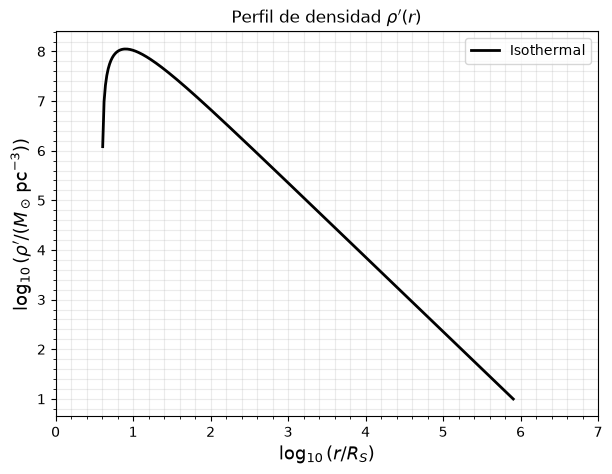

In [31]:
R_S = schwarzschild_radius(M)

r_values = np.logspace(np.log10(4.05 * R_S),np.log10(0.2),300)
rho_values = rho_prime_profile(f_prime_const, r_values, M)
x_values = np.log10(r_values / R_S)
y_values = np.log10(rho_values)

plt.figure(figsize=(7, 5))
plt.plot(x_values,y_values,color="black",lw=2,label="Isothermal")
plt.xlabel(r"$\log_{10}(r/R_S)$", fontsize=13)
plt.ylabel(r"$\log_{10}(\rho'/(M_\odot\,\mathrm{pc}^{-3}))$", fontsize=13)
plt.title(r"Perfil de densidad $\rho'(r)$")
plt.xlim(0, 7)
plt.grid(True, which="both", alpha=0.25)
plt.minorticks_on()
plt.legend(frameon=True)

plt.show()
